# End-to-End E-Commerce Customer Segmentation & Surrogate Modeling

**Business Objective:** In a dynamic E-Commerce environment, understanding customer behavior is key to operational efficiency and targeted marketing strategies. This project aims to:
1. Extract and engineer operational features (logistics and physical dimensions) from raw transaction data.
2. Segment customers naturally using an Unsupervised Learning algorithm (K-Means).
3. Build a Surrogate Model using Supervised Learning (Random Forest) to predict customer segments in real-time within a production environment (Web/API).

**Methodology:**
* **Data Preparation & Feature Engineering:** Extraction of physical dimensions and delivery SLA (Service Level Agreement).
* **Clustering:** Application of K-Means with feature standardization.
* **Model Complexity:** Comparison between a Baseline Model (Decision Tree) and a Tuned Model (Random Forest + K-Fold Cross Validation).
* **Model Evaluation:** Analysis using Classification Reports, Confusion Matrices, and Feature Importances.

In [19]:
# Import standard libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import Machine Learning libraries from Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Visualization settings and warning suppression
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

## 1. Data Understanding & Feature Engineering

The first step is to transform raw E-Commerce operational data into a multi-dimensional customer profile. We will extract logistics metrics (such as delivery time) and calculate the physical dimensions of the packages (Volume), then aggregate them by customer ID.

In [20]:
df_master = pd.read_csv('master_olist_engineered.csv')

# 1. Extracting Time Features & Physical Dimensions
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
df_master['order_delivered_customer_date'] = pd.to_datetime(df_master['order_delivered_customer_date'])

# Calculate delivery duration in days
df_master['delivery_time_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

# Calculate Item Volume (Length x Width x Height)
df_master['product_volume_cm3'] = df_master['product_length_cm'] * df_master['product_height_cm'] * df_master['product_width_cm']

# 2. Assembling Customer Profiles (Multi-Dimensional Aggregation)
customer_behavior = df_master.groupby('customer_id').agg({
    'order_id': 'count',                 
    'freight_value': 'mean',             
    'delivery_time_days': 'mean',        
    'product_weight_g': 'mean',          
    'product_volume_cm3': 'mean',        
    'customer_state': lambda x: 1 if x.mode()[0] == 'SP' else 0 # 1 for Metropolitan, 0 for Other Regions
}).reset_index()

customer_behavior.rename(columns={
    'order_id': 'Total_Items_Bought', 
    'freight_value': 'Avg_Freight_Tolerance',
    'delivery_time_days': 'Avg_Delivery_Days',
    'product_weight_g': 'Avg_Item_Weight_g',
    'product_volume_cm3': 'Avg_Item_Volume_cm3',
    'customer_state': 'Is_Metro_City'
}, inplace=True)

# Drop missing values
customer_behavior = customer_behavior.dropna()

print(f"Customer profiles successfully built for {customer_behavior.shape[0]} customers with 6 features.")
customer_behavior.head()

Customer profiles successfully built for 96470 customers with 6 features.


,customer_id,Total_Items_Bought,Avg_Freight_Tolerance,Avg_Delivery_Days,Avg_Item_Weight_g,Avg_Item_Volume_cm3,Is_Metro_City
0,00012a2ce6f8dcda20d059ce98491703,1,24.94,13.0,4267.0,39468.0,1
1,000161a058600d5901f007fab4c27140,1,12.51,9.0,150.0,352.0,0
2,0001fd6190edaaf884bcaf3d49edf079,1,15.43,5.0,750.0,16905.0,0
3,0002414f95344307404f0ace7a26f1d5,1,29.45,28.0,1600.0,28800.0,0
4,000379cdec625522490c315e70c7a9fb,1,14.01,11.0,800.0,15300.0,1


## 2. Clustering (Unsupervised Learning)

Since we lack predefined "Segment" labels from the E-Commerce system, we utilize **K-Means Clustering** to automatically group customers into 3 business segments based on the 6 engineered dimensions. 

*Note: StandardScaler is required before applying K-Means, as distance-based algorithms are highly sensitive to variations in scale.*

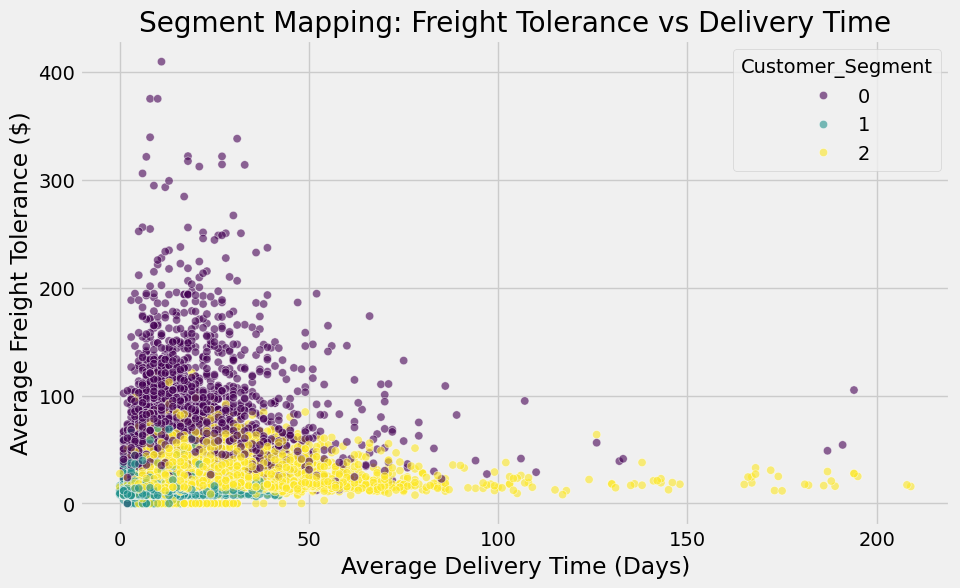

Segment labels successfully generated.


In [21]:
# Exclude the ID column (irrelevant for distance computation)
features = customer_behavior[[
    'Total_Items_Bought', 'Avg_Freight_Tolerance', 'Avg_Delivery_Days', 
    'Avg_Item_Weight_g', 'Avg_Item_Volume_cm3', 'Is_Metro_City'
]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_behavior['Customer_Segment'] = kmeans.fit_predict(scaled_features)

# Visualize Clustering Results
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_behavior, 
    x='Avg_Delivery_Days', 
    y='Avg_Freight_Tolerance', 
    hue='Customer_Segment', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Segment Mapping: Freight Tolerance vs Delivery Time')
plt.xlabel('Average Delivery Time (Days)')
plt.ylabel('Average Freight Tolerance ($)')
plt.show()

print("Segment labels successfully generated.")

## 3. Prediction Model Development (Supervised Learning)

Running K-Means in real-time on a production server is computationally expensive. Therefore, we train a Supervised Learning model (Random Forest) to learn the patterns generated by K-Means, acting as a **Surrogate Model**.

**Preventing Data Leakage:**
To ensure the model generalizes rather than memorizing the cluster assignments (100% overfitting), we intentionally exclude the `Avg_Item_Volume_cm3` variable from the training matrix.

In [22]:
# Feature set (X) excludes Volume to prevent target leakage
X = customer_behavior[[
    'Total_Items_Bought', 
    'Avg_Freight_Tolerance', 
    'Avg_Delivery_Days', 
    'Avg_Item_Weight_g', 
    'Is_Metro_City'
]]
y = customer_behavior['Customer_Segment']

# Data Splitting (80% Training, 20% Testing) using stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data: {X_train.shape[0]} rows | Testing Data: {X_test.shape[0]} rows")

Training Data: 77176 rows | Testing Data: 19294 rows


### 3.1 Baseline Model (Decision Tree)
We begin with a simple single decision tree algorithm to establish the baseline performance metric for our system.

In [23]:
print("--- Experiment 1: Baseline Decision Tree ---")
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

dt_pred = dt_base.predict(X_test)
print(classification_report(y_test, dt_pred))

--- Experiment 1: Baseline Decision Tree ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1177
           1       0.99      0.99      0.99      7624
           2       0.99      0.99      0.99     10493

    accuracy                           0.99     19294
   macro avg       0.96      0.96      0.96     19294
weighted avg       0.99      0.99      0.99     19294



### 3.2 Model Complexity & Hyperparameter Tuning (Random Forest)

To meet production standards, we upgrade the algorithm to a Random Forest ensemble. We utilize **GridSearchCV** alongside **5-Fold Stratified Cross-Validation** to automatically search for optimal parameters and prevent overfitting.

In [24]:
print("--- Experiment 2: Tuned Random Forest (5-Fold CV) ---")

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],          
    'max_depth': [5, 10, None],         
    'min_samples_split': [5, 10],       
    'class_weight': ['balanced']        
}

# Cross-validation scheme
cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Execute automated tuning
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_scheme, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Extract the best model
rf_best = grid_search.best_estimator_

print(f"\nOptimal Parameters Found: {grid_search.best_params_}")

rf_pred = rf_best.predict(X_test)
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, rf_pred))

--- Experiment 2: Tuned Random Forest (5-Fold CV) ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Optimal Parameters Found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1177
           1       0.99      0.99      0.99      7624
           2       1.00      0.99      0.99     10493

    accuracy                           0.99     19294
   macro avg       0.96      0.97      0.97     19294
weighted avg       0.99      0.99      0.99     19294



## 4. Insights, Interpretations, and Conclusions

In an enterprise-level system, AI models must not operate as "Black Boxes." Business stakeholders require operational transparency regarding how segmentation decisions are made. 
We evaluate prediction blind spots using a **Confusion Matrix** and interpret the underlying logic using **Feature Importances**.

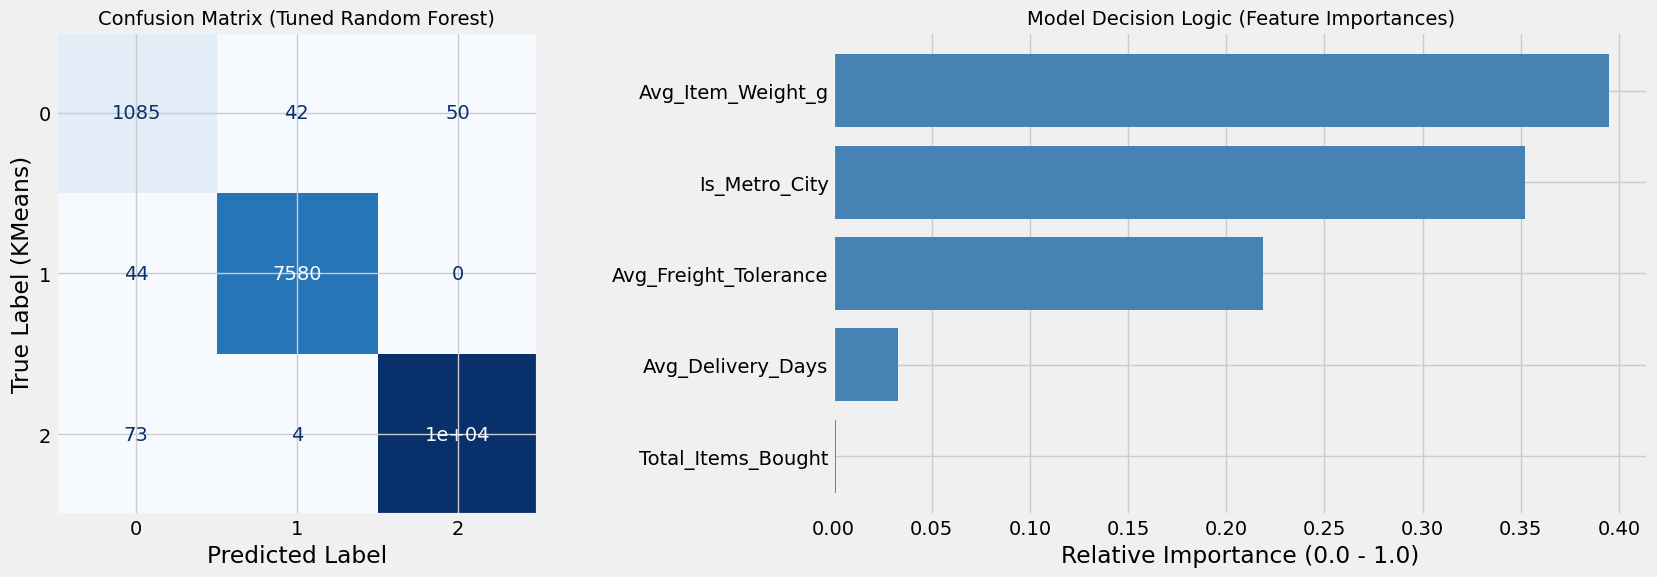

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# PLOT 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    rf_pred, 
    ax=axes[0], 
    cmap='Blues', 
    colorbar=False
)
axes[0].set_title('Confusion Matrix (Tuned Random Forest)', fontsize=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label (KMeans)')

# PLOT 2: Feature Importances
importances = rf_best.feature_importances_
indices = np.argsort(importances)

axes[1].barh(range(len(indices)), importances[indices], color='steelblue', align='center')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([X.columns[i] for i in indices])
axes[1].set_xlabel('Relative Importance (0.0 - 1.0)')
axes[1].set_title('Model Decision Logic (Feature Importances)', fontsize=14)

plt.tight_layout()
plt.show()

## 5. System Integration

Following cross-validation and evaluation, the tuned architecture is ready for production. The model is exported as a binary object (.pkl) to be integrated into the E-Commerce Web/API interface.

In [26]:
# Export the Surrogate Model
joblib.dump(rf_best, 'ecommerce_advanced_model.pkl')

['ecommerce_advanced_model.pkl']